# Telco Customer Churn — Exploratory Data Analysis

**Tahap:** 2 — Data Analyst (CRISP-DM)
**Tujuan:** Memahami karakteristik pelanggan churn & menemukan insight bisnis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv(r"C:\Users\hp\Downloads\telco-churn-portfolio\data\processed\telco_churn_clean.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7010, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [6]:
print("Tipe data & missing value:")
df.info()

print("\nStatistik deskriptif:")
df.describe()

Tipe data & missing value:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod  

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388,0.264907
std,0.369180,24.520441,30.064769,2266.820832,0.441315
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.750000,408.312500,0.000000
50%,0.000000,29.000000,70.400000,1403.875000,0.000000
75%,0.000000,56.000000,89.900000,3807.837500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


### 📊 Insight Awal dari Statistik Deskriptif

1. **Class Imbalance** — Hanya 26.49% pelanggan yang churn. Ini mengonfirmasi bahwa akurasi bukan metrik yang tepat; kita perlu fokus pada **Recall** agar model mampu menangkap pelanggan berisiko.

2. **Distribusi Tenure** — 25% pelanggan hanya bertahan ≤9 bulan. Artinya, **masa kritis retensi adalah tahun pertama berlangganan**.

3. **Variasi MonthlyCharges** — Biaya bulanan berkisar $18.25–$118.75 dengan rata-rata $64.89. Perlu dianalisis lebih lanjut apakah harga tinggi berkorelasi dengan churn.

4. **Tipe Data** — Terdapat 15 kolom bertipe object (kategorikal) dan 5 kolom numerik. Untuk modeling nanti, kolom kategorikal perlu di-encode.

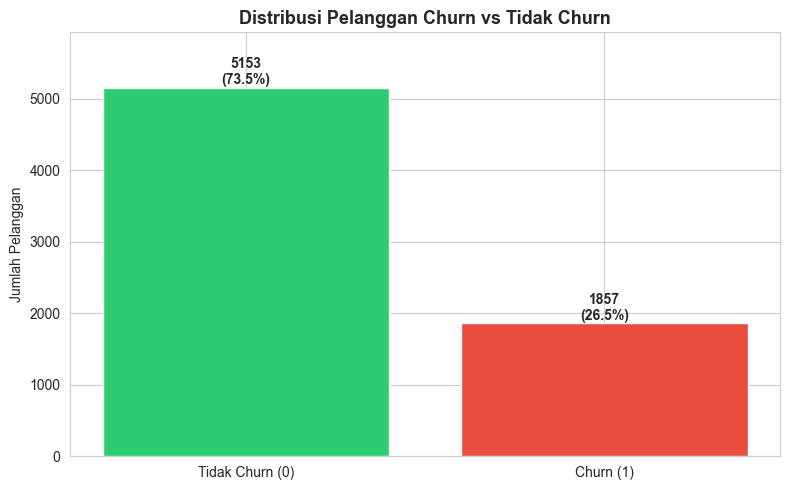

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

churn_counts = df["Churn"].value_counts()
colors = ["#2ecc71", "#e74c3c"]  # hijau, merah
bars = ax.bar(["Tidak Churn (0)", "Churn (1)"], 
              churn_counts.values, 
              color=colors)

# Tambahkan label jumlah & persentase
total = churn_counts.sum()
for bar, count in zip(bars, churn_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 50,
            f"{count}\n({pct:.1f}%)",
            ha="center", fontweight="bold")

ax.set_title("Distribusi Pelanggan Churn vs Tidak Churn")
ax.set_ylabel("Jumlah Pelanggan")
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.show()

### 🎯 Insight 1: Class Imbalance

Visualisasi menunjukkan **class imbalance yang signifikan**:
- 73.5% pelanggan tidak churn (5.153 orang)
- 26.5% pelanggan churn (1.857 orang)

**Implikasi bisnis & teknis:**
- **Untuk bisnis:** Churn rate 26.5% adalah baseline. Setiap strategi retensi harus dibandingkan dengan angka ini.
- **Untuk modeling:** Akurasi bukan metrik yang tepat — model "malas" yang selalu prediksi "tidak churn" akan dapat akurasi 73.5%. Saya akan menggunakan **Recall** sebagai metrik utama agar model mampu menangkap pelanggan berisiko.

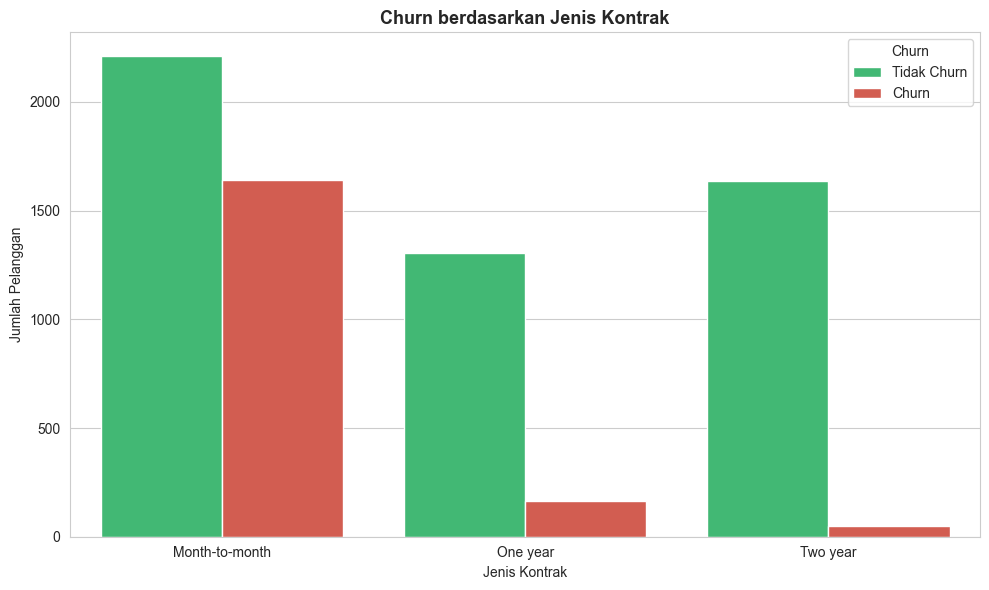


Churn rate per jenis kontrak:
  Month-to-month       : 42.6%
  One year             : 11.3%
  Two year             : 2.8%


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x="Contract", hue="Churn",
              palette=["#2ecc71", "#e74c3c"], ax=ax)

ax.set_title("Churn berdasarkan Jenis Kontrak")
ax.set_xlabel("Jenis Kontrak")
ax.set_ylabel("Jumlah Pelanggan")
ax.legend(title="Churn", labels=["Tidak Churn", "Churn"])
plt.tight_layout()
plt.show()

# Churn rate per kontrak
churn_rate = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100
print("\nChurn rate per jenis kontrak:")
for contract, rate in churn_rate.items():
    print(f"  {contract:20s} : {rate:.1f}%")
    

### 🎯 Insight 2: Kontrak adalah Prediktor Churn Terkuat

Churn rate berdasarkan jenis kontrak:
- **Month-to-month: 42.6%** (paling berisiko)
- **One year: 11.3%**
- **Two year: 2.8%** (paling setia)

**Selisih 15x** antara month-to-month dan two year menunjukkan bahwa **komitmen kontrak adalah faktor penentu retensi**. 

**Implikasi bisnis:**
- Setiap pelanggan month-to-month yang berhasil di-upgrade ke kontrak tahunan berpotensi menurunkan churn rate mereka dari 42.6% menjadi 11.3% — **pengurangan risiko hingga 73%**.
- Rekomendasi: program insentif untuk upgrade kontrak, terutama pada bulan-bulan awal berlangganan.

**Implikasi teknis:**
- Fitur `Contract` akan menjadi salah satu prediktor terkuat di model. Ini akan terkonfirmasi saat analisis feature importance di tahap modeling.

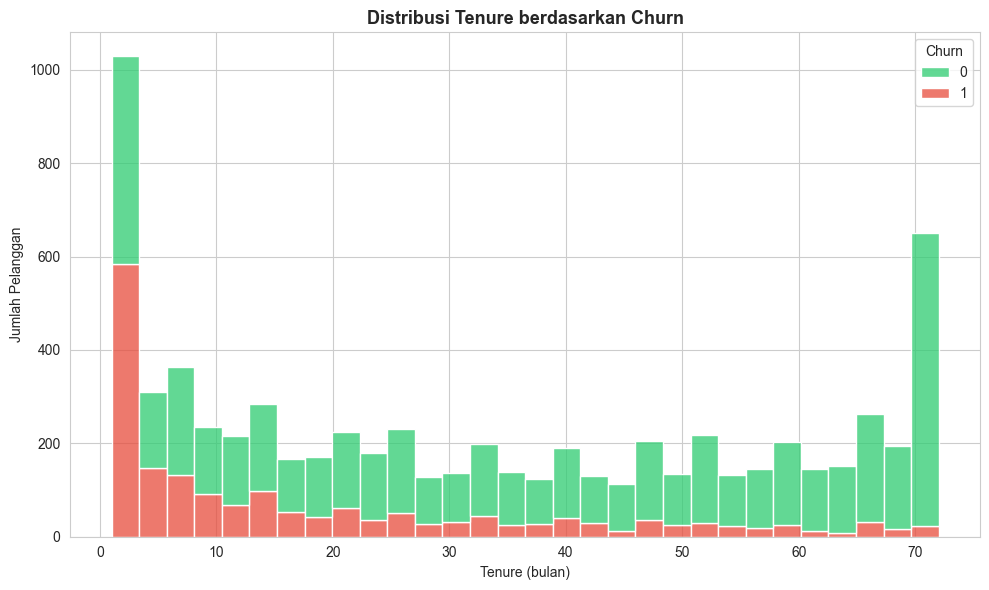


Rata-rata tenure:
Churn
0    37.721133
1    18.088853
Name: tenure, dtype: float64

Median tenure:
Churn
0    38.0
1    10.0
Name: tenure, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30,
             palette=["#2ecc71", "#e74c3c"], 
             multiple="stack", ax=ax)

ax.set_title("Distribusi Tenure berdasarkan Churn")
ax.set_xlabel("Tenure (bulan)")
ax.set_ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

# Rata-rata tenure per status churn
print("\nRata-rata tenure:")
print(df.groupby("Churn")["tenure"].mean())

# Median tenure
print("\nMedian tenure:")
print(df.groupby("Churn")["tenure"].median())

### 🎯 Insight 3: Masa Kritis Retensi adalah 10 Bulan Pertama

**Median tenure:**
- Pelanggan churn: **10 bulan**
- Pelanggan tidak churn: **38 bulan**
- Selisih: 28 bulan (3.8x lebih lama)

**Pola visual yang terlihat:**
- Bar merah (churn) **menumpuk di sebelah kiri** (bulan 0–10)
- Bar hijau (tidak churn) **menyebar merata** seiring waktu
- Ada **lonjakan besar di bulan 70+** — pelanggan veteran hampir tidak pernah churn

**Interpretasi:**
Terdapat **"titik kritis" di 10 bulan pertama**. Pelanggan yang berhasil melewati periode ini cenderung menjadi pelanggan jangka panjang. Fenomena ini konsisten dengan **survivorship bias** — pelanggan yang selamat dari masa kritis menjadi sangat loyal.

**Implikasi bisnis:**
- **ROI tertinggi ada di program onboarding** (0-90 hari pertama).
- Setiap pelanggan baru yang berhasil dipertahankan hingga bulan ke-12 memiliki **probabilitas churn jauh lebih rendah**.
- Strategi retensi sebaiknya **diprioritaskan pada pelanggan baru**, bukan pelanggan lama.

C:\Users\hp\AppData\Local\Temp\ipykernel_18520\1776780284.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges",
C:\Users\hp\AppData\Local\Temp\ipykernel_18520\1776780284.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Tidak Churn", "Churn"])


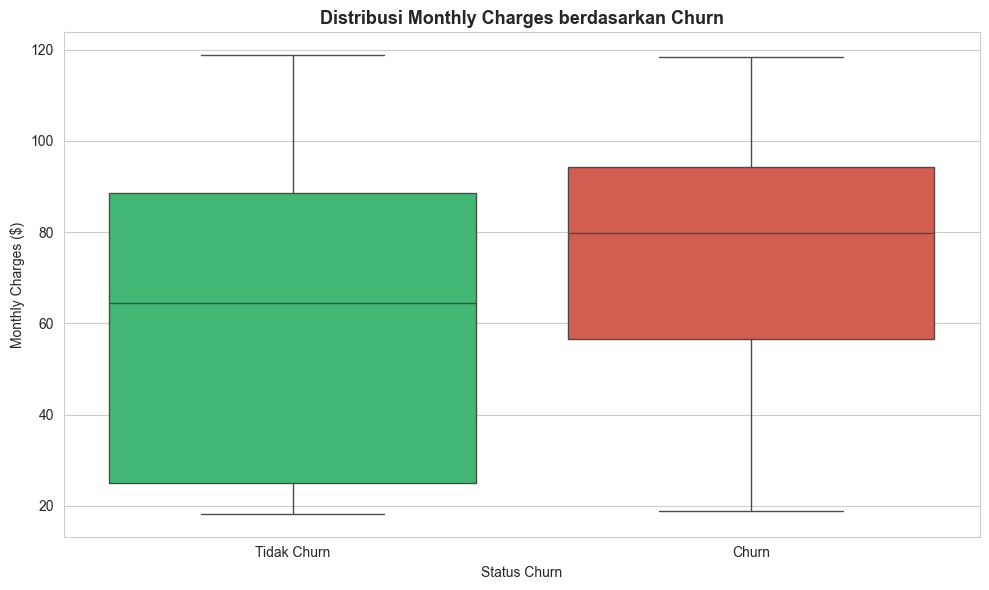


Rata-rata Monthly Charges:
Churn
0    61.387415
1    74.604308
Name: MonthlyCharges, dtype: float64

Median Monthly Charges:
Churn
0    64.55
1    79.70
Name: MonthlyCharges, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges",
            palette=["#2ecc71", "#e74c3c"], ax=ax)

ax.set_title("Distribusi Monthly Charges berdasarkan Churn")
ax.set_xticklabels(["Tidak Churn", "Churn"])
ax.set_xlabel("Status Churn")
ax.set_ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

# Statistik harga per status
print("\nRata-rata Monthly Charges:")
print(df.groupby("Churn")["MonthlyCharges"].mean())
print("\nMedian Monthly Charges:")
print(df.groupby("Churn")["MonthlyCharges"].median())

## 📌 Ringkasan: 4 Insight Utama dari EDA

| # | Insight | Angka Kunci | Implikasi Bisnis |
|---|---|---|---|
| 1 | Class Imbalance | 26.5% churn | Gunakan Recall sebagai metrik model |
| 2 | Kontrak Month-to-Month | 42.6% churn (15x lebih tinggi dari 2-year) | Dorong upgrade ke kontrak tahunan |
| 3 | Masa Kritis 10 Bulan | Median tenure churn = 10 bulan | Fokus program retensi di tahun pertama |
| 4 | Harga Tinggi | Churners bayar $79.70 vs $64.55 | Tinjau strategi pricing & value-add |

### 🎯 Persona Pelanggan Paling Berisiko Churn

Kombinasi karakteristik yang paling berbahaya:
- Kontrak **month-to-month**
- Berlangganan **<12 bulan**
- Membayar **>$70/bulan**

### 💡 Rekomendasi Strategi Retensi

1. **Program onboarding** (0-90 hari) dengan insentif khusus
2. **Upgrade path** ke kontrak tahunan dengan diskon
3. **Value-add** untuk pelanggan dengan biaya tinggi
4. **Early warning system** — tandai pelanggan yang masuk persona berisiko

### ➡️ Selanjutnya

Insight ini akan menjadi dasar untuk **Tahap 4: Modeling** — membangun model ML yang dapat memprediksi churn secara otomatis.